In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


# History file

In [78]:
# hst = np.loadtxt("../turb_template_2/parthenon.out1.hst", skiprows=1)
hst = np.loadtxt("parthenon.out1.hst", skiprows=1)

In [79]:
time = hst[:, 0]
KE = hst[:, 8]
mass = hst[:, 4]

In [80]:
vturb = np.sqrt(2*KE/ mass)

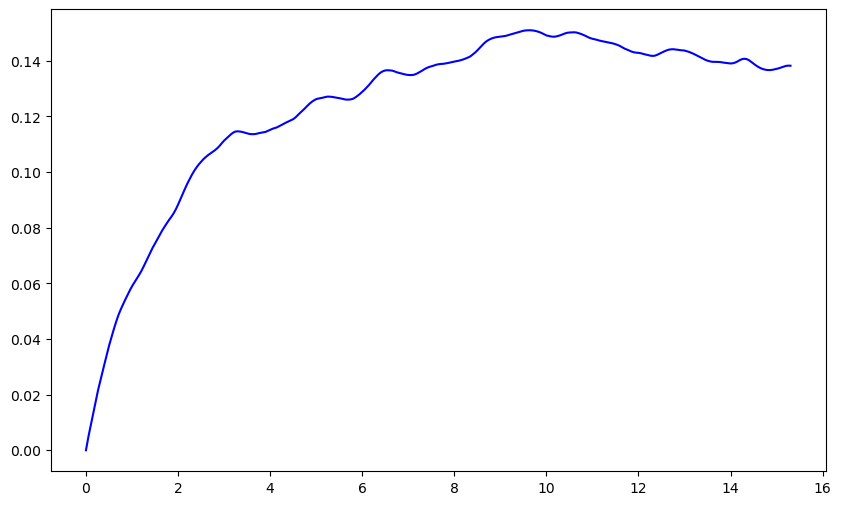

In [81]:
plt.figure(figsize=(10, 6))
plt.plot(time, vturb, label="Turbulent Velocity", color='blue')

In [69]:
# vturb = 0.3
# vturb = 0.45
vturb = 0.14
Lbox = 1.0
rho = 0.25

In [64]:
# pdot = 0.5* rho * vturb**2 * Lbox**2
pdot = 0.5* vturb**2 / Lbox
print(pdot)

0.009800000000000001


# HDF5 outputs

In [17]:
data_file = phdf.phdf("parthenon.prim.00025.phdf")
data_file.Variables

['Blocks',
 'Info',
 'Input',
 'Levels',
 'Locations',
 'LogicalLocations',
 'Params',
 'VolumeLocations',
 'acc',
 'prim',
 'tracers']

In [18]:
prim = data_file.Get("prim", flatten=False)
np.shape(prim)

(8, 5, 32, 32, 32)

In [14]:
acc = data_file.Get("acc")
np.shape(acc)

(8, 3, 32768)

In [15]:
data_file

# Tracers

In [82]:
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


In [ ]:
filenames = [f"parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(90)] 

rho_list = []

for filename in filenames:
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    xs = tracers.x
    ys = tracers.y
    zs = tracers.z
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    rho_list.append(rho)

    print(i)


KeyboardInterrupt: 